In [9]:
# Cell 1: imports + basic settings
import re
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [10]:
# Cell 2: load data (robust path)
path_candidates = [
    "2026_MCM_Problem_C_Data.csv",
    "2026_MCM_Problem_C_Data.csv",
]
for p in path_candidates:
    try:
        df_raw = pd.read_csv(p)
        data_path = p
        break
    except FileNotFoundError:
        continue

print("Loaded:", data_path)
print("Shape:", df_raw.shape)
df_raw.head(3)


Loaded: 2026_MCM_Problem_C_Data.csv
Shape: (421, 53)


,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,week1_judge2_score,week1_judge3_score,week1_judge4_score,week2_judge1_score,week2_judge2_score,week2_judge3_score,week2_judge4_score,week3_judge1_score,week3_judge2_score,week3_judge3_score,week3_judge4_score,week4_judge1_score,week4_judge2_score,week4_judge3_score,week4_judge4_score,week5_judge1_score,week5_judge2_score,week5_judge3_score,week5_judge4_score,week6_judge1_score,week6_judge2_score,week6_judge3_score,week6_judge4_score,week7_judge1_score,week7_judge2_score,week7_judge3_score,week7_judge4_score,week8_judge1_score,week8_judge2_score,week8_judge3_score,week8_judge4_score,week9_judge1_score,week9_judge2_score,week9_judge3_score,week9_judge4_score,week10_judge1_score,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,7.0,6.0,NaN,8.0,9.0,9.0,NaN,9.0,8.0,7.0,NaN,7.0,8.0,6.0,NaN,9.0,9.0,9.0,NaN,9.0,9.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,4.0,4.0,NaN,5.0,6.0,6.0,NaN,6.0,7.0,8.0,NaN,9.0,9.0,8.0,NaN,8.5,7.5,7.5,NaN,8.5,9.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,7.0,6.0,NaN,5.0,4.0,5.0,NaN,5.0,4.0,4.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. 列名清洗 + 基本一致性检查

In [11]:
# Cell 3: column rename + basic string cleanup + duplicate check
df = df_raw.copy()

# rename the slash column for easier coding
df = df.rename(columns={"celebrity_homecountry/region": "celebrity_homecountry_region"})

# strip whitespace for text columns (keep NaN as NaN)
text_cols = [
    "celebrity_name", "ballroom_partner", "celebrity_industry",
    "celebrity_homestate", "celebrity_homecountry_region", "results"
]
for c in text_cols:
    df[c] = df[c].astype("string").str.strip()

# key uniqueness check: (season, celebrity_name) should be unique
dup = df.duplicated(subset=["season", "celebrity_name"]).sum()
print("Duplicate (season, celebrity_name):", dup)
df.dtypes.head(12)


Duplicate (season, celebrity_name): 0


celebrity_name                  string[python]
ballroom_partner                string[python]
celebrity_industry              string[python]
celebrity_homestate             string[python]
celebrity_homecountry_region    string[python]
celebrity_age_during_season              int64
season                                   int64
results                         string[python]
placement                                int64
week1_judge1_score                     float64
week1_judge2_score                     float64
week1_judge3_score                     float64
dtype: object

### 解析 results 字段
从results中提取：
elim_week_result：第几周被淘汰
is_withdrew：是否中途退赛
is_place：是否进入最终名次（1st–5th Place）

In [12]:
# Cell 4: parse results -> elimination week / withdrew / finals-like flags
df["elim_week_result"] = df["results"].str.extract(r"Eliminated Week\s+(\d+)", expand=False).astype("Float64")
df["is_withdrew"] = df["results"].str.contains(r"Withdrew", na=False)
df["is_place"] = df["results"].str.contains(r"Place", na=False)   # 1st/2nd/3rd/4th/5th Place etc.

print(df["results"].value_counts().head(15))
df[["season","celebrity_name","results","placement","elim_week_result","is_withdrew"]].head(10)

results
Eliminated Week 2     40
Eliminated Week 7     36
Eliminated Week 8     36
Eliminated Week 4     35
1st Place             34
2nd Place             34
3rd Place             34
Eliminated Week 3     33
Eliminated Week 9     32
Eliminated Week 6     31
Eliminated Week 5     24
Eliminated Week 1     16
Eliminated Week 10    11
Withdrew              10
4th Place              8
Name: count, dtype: Int64


,season,celebrity_name,results,placement,elim_week_result,is_withdrew
0,1,John O'Hurley,2nd Place,2,<NA>,False
1,1,Kelly Monaco,1st Place,1,<NA>,False
2,1,Evander Holyfield,Eliminated Week 3,5,3.0,False
3,1,Rachel Hunter,Eliminated Week 4,4,4.0,False
4,1,Joey McIntyre,3rd Place,3,<NA>,False
5,1,Trista Sutter,Eliminated Week 2,6,2.0,False
6,2,Tatum O'Neal,Eliminated Week 2,9,2.0,False
7,2,Tia Carrere,Eliminated Week 5,6,5.0,False
8,2,George Hamilton,Eliminated Week 6,5,6.0,False
9,2,Lisa Rinna,Eliminated Week 7,4,7.0,False


### 确定每个 season 的真实周数 + 选手活跃区间
找出week*judge列，确认周数
active_until（在第 w 周，这个人是否还在比赛中？）

In [13]:
# Cell 5: identify week-score columns + compute season_max_week using POSITIVE scores
week_cols = [c for c in df.columns if re.match(r"week\d+_judge\d+_score$", c)]
print("Number of week score columns:", len(week_cols))
print("Example cols:", week_cols[:6], "...", week_cols[-3:])

MAX_WEEK = max(int(re.findall(r"week(\d+)_", c)[0]) for c in week_cols)
print("MAX_WEEK inferred:", MAX_WEEK)

# total score per week per contestant (treat all-NaN week as NaN)
totals = {}
for w in range(1, MAX_WEEK + 1):
    cols = [f"week{w}_judge{j}_score" for j in range(1, 5)]
    s = df[cols].sum(axis=1, skipna=True)
    all_nan = df[cols].isna().all(axis=1)
    totals[w] = s.mask(all_nan, np.nan)

total_df = pd.DataFrame(totals)  # columns are week numbers

# season_max_week: last week where ANY contestant has positive total (not just non-null 0-fill)
season_week_positive = total_df.gt(0).groupby(df["season"]).any()
season_max_week = season_week_positive.apply(lambda row: row[::-1].idxmax() if row.any() else np.nan, axis=1).astype(int)

df["season_max_week"] = df["season"].map(season_max_week)

# last week with positive score (useful for withdrew)
df["last_week_positive"] = total_df.apply(lambda r: (r[r > 0].index.max() if (r > 0).any() else np.nan), axis=1)

# active_until: define the last week they are "in competition / eligible"
# - Eliminated Week k -> k
# - Place (finalists etc) -> season_max_week
# - Withdrew -> assume last week with positive judge score (working assumption)
df["active_until"] = df["elim_week_result"]

mask_place = df["active_until"].isna() & df["is_place"]
df.loc[mask_place, "active_until"] = df.loc[mask_place, "season_max_week"]

mask_withdrew = df["is_withdrew"]
df.loc[mask_withdrew, "active_until"] = df.loc[mask_withdrew, "last_week_positive"]

# fallback (should be rare): set to season_max_week
df["active_until"] = df["active_until"].fillna(df["season_max_week"]).astype(float)

df[["season","celebrity_name","results","season_max_week","active_until","last_week_positive"]].head(12)


Number of week score columns: 44
Example cols: ['week1_judge1_score', 'week1_judge2_score', 'week1_judge3_score', 'week1_judge4_score', 'week2_judge1_score', 'week2_judge2_score'] ... ['week11_judge2_score', 'week11_judge3_score', 'week11_judge4_score']
MAX_WEEK inferred: 11


,season,celebrity_name,results,season_max_week,active_until,last_week_positive
0,1,John O'Hurley,2nd Place,6,6.0,6
1,1,Kelly Monaco,1st Place,6,6.0,6
2,1,Evander Holyfield,Eliminated Week 3,6,3.0,3
3,1,Rachel Hunter,Eliminated Week 4,6,4.0,4
4,1,Joey McIntyre,3rd Place,6,6.0,5
5,1,Trista Sutter,Eliminated Week 2,6,2.0,2
6,2,Tatum O'Neal,Eliminated Week 2,8,2.0,2
7,2,Tia Carrere,Eliminated Week 5,8,5.0,5
8,2,George Hamilton,Eliminated Week 6,8,6.0,6
9,2,Lisa Rinna,Eliminated Week 7,8,7.0,7


### 清洗“假 0 分”
1. 选手在 active_until 之前：这一周所有 judge 分数都是 0，转为Nan
2. week > active_until，week 仍在 season 内，原始数据给了 0 → 全部转成 NaN

In [14]:
# Cell 6: clean score matrix
# Goal:
#  (1) If a contestant should still be active (week <= active_until) but all recorded scores are 0 -> impossible -> treat as missing (NaN)
#  (2) For post-active weeks within the season, turn the 0-fill into NaN (since it's just a sentinel for "already eliminated")

df_clean = df.copy()

impossible_zero_cases = []
for w in range(1, MAX_WEEK + 1):
    cols = [f"week{w}_judge{j}_score" for j in range(1, 5)]

    # week is within season run
    in_season_week = w <= df_clean["season_max_week"]

    # should still be active/eligible
    should_be_active = (w <= df_clean["active_until"]) & in_season_week

    # "all non-missing scores are 0" and at least one score is recorded
    all_zero = df_clean[cols].fillna(0).eq(0).all(axis=1) & df_clean[cols].notna().any(axis=1)

    mask_impossible = all_zero & should_be_active
    if mask_impossible.any():
        impossible_zero_cases.append((w, int(mask_impossible.sum())))
        df_clean.loc[mask_impossible, cols] = np.nan

print("Impossible all-zero weeks fixed (week, count):", impossible_zero_cases)

# convert post-active 0-fill to NaN (keep NaN as NaN)
for w in range(1, MAX_WEEK + 1):
    cols = [f"week{w}_judge{j}_score" for j in range(1, 5)]
    post_active = (w > df_clean["active_until"]) & (w <= df_clean["season_max_week"])
    df_clean.loc[post_active, cols] = df_clean.loc[post_active, cols].replace(0, np.nan)

# quick sanity: remaining literal zeros should be very rare (ideally none)
zero_left = (df_clean[week_cols] == 0).sum().sum()
print("Total literal zeros left in week_cols:", int(zero_left))
df_clean.head(3)


Impossible all-zero weeks fixed (week, count): [(2, 1), (6, 1), (10, 1)]
Total literal zeros left in week_cols: 0


,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,season,results,placement,week1_judge1_score,week1_judge2_score,week1_judge3_score,week1_judge4_score,week2_judge1_score,week2_judge2_score,week2_judge3_score,week2_judge4_score,week3_judge1_score,week3_judge2_score,week3_judge3_score,week3_judge4_score,week4_judge1_score,week4_judge2_score,week4_judge3_score,week4_judge4_score,week5_judge1_score,week5_judge2_score,week5_judge3_score,week5_judge4_score,week6_judge1_score,week6_judge2_score,week6_judge3_score,week6_judge4_score,week7_judge1_score,week7_judge2_score,week7_judge3_score,week7_judge4_score,week8_judge1_score,week8_judge2_score,week8_judge3_score,week8_judge4_score,week9_judge1_score,week9_judge2_score,week9_judge3_score,week9_judge4_score,week10_judge1_score,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score,elim_week_result,is_withdrew,is_place,season_max_week,last_week_positive,active_until
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,7.0,6.0,NaN,8.0,9.0,9.0,NaN,9.0,8.0,7.0,NaN,7.0,8.0,6.0,NaN,9.0,9.0,9.0,NaN,9.0,9.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,False,True,6,6,6.0
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,4.0,4.0,NaN,5.0,6.0,6.0,NaN,6.0,7.0,8.0,NaN,9.0,9.0,8.0,NaN,8.5,7.5,7.5,NaN,8.5,9.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,False,True,6,6,6.0
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,7.0,6.0,NaN,5.0,4.0,5.0,NaN,5.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,False,False,6,3,3.0


### 一行 = 一个选手 × 一周 × 一个评委

In [15]:
# Cell 7: reshape to long judge-level table: df_long_judge
id_cols = [
    "season","celebrity_name","ballroom_partner","celebrity_industry",
    "celebrity_homestate","celebrity_homecountry_region",
    "celebrity_age_during_season","results","placement",
    "elim_week_result","is_withdrew","is_place",
    "season_max_week","active_until","last_week_positive",
]

df_long_judge = df_clean.melt(
    id_vars=id_cols,
    value_vars=week_cols,
    var_name="week_judge",
    value_name="judge_score",
)

tmp = df_long_judge["week_judge"].str.extract(r"week(\d+)_judge(\d+)_score")
df_long_judge["week"] = tmp[0].astype(int)
df_long_judge["judge"] = tmp[1].astype(int)
df_long_judge = df_long_judge.drop(columns=["week_judge"])

# flags
df_long_judge["is_show_week"] = df_long_judge["week"] <= df_long_judge["season_max_week"]
df_long_judge["eligible"] = (df_long_judge["week"] <= df_long_judge["active_until"]) & df_long_judge["is_show_week"]

df_long_judge.sort_values(["season","celebrity_name","week","judge"]).head(12)


,season,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,results,placement,elim_week_result,is_withdrew,is_place,season_max_week,active_until,last_week_positive,judge_score,week,judge,is_show_week,eligible
2,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,5.0,1,1,True,True
423,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,7.0,1,2,True,True
844,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,6.0,1,3,True,True
1265,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,NaN,1,4,True,True
1686,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,5.0,2,1,True,True
2107,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,4.0,2,2,True,True
2528,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,5.0,2,3,True,True
2949,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,NaN,2,4,True,True
3370,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,5.0,3,1,True,True
3791,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,4.0,3,2,True,True


### 构建周级汇总表（df_weekly）

In [16]:
# Cell 8: weekly aggregated table: df_weekly (contestant-week)
# aggregate only show weeks
g = df_long_judge[df_long_judge["is_show_week"]].groupby(["season","celebrity_name","week"], as_index=False)

df_weekly = g.agg(
    total_judge_score=("judge_score", "sum"),
    mean_judge_score=("judge_score", "mean"),
    n_judges_scored=("judge_score", lambda x: int(x.notna().sum())),
)

# sum() on all-NaN becomes 0; fix it to NaN
df_weekly.loc[df_weekly["n_judges_scored"].eq(0), "total_judge_score"] = np.nan

df_weekly["performed"] = df_weekly["total_judge_score"].fillna(0) > 0

# bring back static attributes + eligibility
static_cols = [
    "season","celebrity_name","ballroom_partner","celebrity_industry",
    "celebrity_homestate","celebrity_homecountry_region",
    "celebrity_age_during_season","results","placement",
    "season_max_week","active_until","elim_week_result","is_withdrew","is_place",
]
df_static = df_clean[static_cols].drop_duplicates(subset=["season","celebrity_name"])

df_weekly = df_weekly.merge(df_static, on=["season","celebrity_name"], how="left")
df_weekly["eligible"] = (df_weekly["week"] <= df_weekly["active_until"]) & (df_weekly["week"] <= df_weekly["season_max_week"])

# judge rank and percent among performed contestants (weekly)
mask_perf = df_weekly["performed"]
df_weekly.loc[mask_perf, "judge_rank"] = (
    df_weekly[mask_perf].groupby(["season","week"])["total_judge_score"]
    .rank(method="average", ascending=False)
)

week_sum = df_weekly[mask_perf].groupby(["season","week"])["total_judge_score"].transform("sum")
df_weekly.loc[mask_perf, "judge_percent"] = df_weekly.loc[mask_perf, "total_judge_score"] / week_sum

df_weekly.sort_values(["season","week","judge_rank"]).head(15)


,season,celebrity_name,week,total_judge_score,mean_judge_score,n_judges_scored,performed,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,results,placement,season_max_week,active_until,elim_week_result,is_withdrew,is_place,eligible,judge_rank,judge_percent
6,1,Joey McIntyre,1,20.0,6.666667,3,True,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3rd Place,3,6,6.0,<NA>,False,True,True,2.0,0.183486
12,1,John O'Hurley,1,20.0,6.666667,3,True,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2nd Place,2,6,6.0,<NA>,False,True,True,2.0,0.183486
24,1,Rachel Hunter,1,20.0,6.666667,3,True,Jonathan Roberts,Model,<NA>,New Zealand,35,Eliminated Week 4,4,6,4.0,4.0,False,False,True,2.0,0.183486
0,1,Evander Holyfield,1,18.0,6.000000,3,True,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,6,3.0,3.0,False,False,True,4.5,0.165138
30,1,Trista Sutter,1,18.0,6.000000,3,True,Louis van Amstel,TV Personality,Indiana,United States,32,Eliminated Week 2,6,6,2.0,2.0,False,False,True,4.5,0.165138
18,1,Kelly Monaco,1,13.0,4.333333,3,True,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1st Place,1,6,6.0,<NA>,False,True,True,6.0,0.119266
13,1,John O'Hurley,2,26.0,8.666667,3,True,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2nd Place,2,6,6.0,<NA>,False,True,True,1.0,0.214876
25,1,Rachel Hunter,2,24.0,8.000000,3,True,Jonathan Roberts,Model,<NA>,New Zealand,35,Eliminated Week 4,4,6,4.0,4.0,False,False,True,2.0,0.198347
7,1,Joey McIntyre,2,21.0,7.000000,3,True,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3rd Place,3,6,6.0,<NA>,False,True,True,3.0,0.173554
31,1,Trista Sutter,2,19.0,6.333333,3,True,Louis van Amstel,TV Personality,Indiana,United States,32,Eliminated Week 2,6,6,2.0,2.0,False,False,True,4.0,0.157025


### df_roster每周在场选手集合（eligible的选手）; df_elim_events淘汰事件表

In [17]:
# Cell 9: build "weekly roster" and "elimination events" from eligibility
# roster: every contestant-week with eligible flag
df_roster = df_weekly[["season","celebrity_name","week","eligible","season_max_week"]].copy()
df_roster = df_roster.sort_values(["season","celebrity_name","week"])

# eliminate at end of week w if eligible at w and NOT eligible at w+1
df_roster["eligible_next"] = df_roster.groupby(["season","celebrity_name"])["eligible"].shift(-1)

elim_rows = df_roster[(df_roster["eligible"]) & (~df_roster["eligible_next"].fillna(False))].copy()
elim_rows["elim_at_end_of_week"] = elim_rows["week"]

df_elim_events = (
    elim_rows.groupby(["season","elim_at_end_of_week"], as_index=False)
    .agg(eliminated=("celebrity_name", lambda x: list(x)))
)

# mark final-week "season end" events vs true weekly eliminations
season_last = df_elim_events["season"].map(season_max_week)
df_elim_events["is_final_week_end"] = df_elim_events["elim_at_end_of_week"].eq(season_last)

print("Elimination events rows:", df_elim_events.shape[0])
df_elim_events.head(10)


Elimination events rows: 292


/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_10196/1893706330.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  elim_rows = df_roster[(df_roster["eligible"]) & (~df_roster["eligible_next"].fillna(False))].copy()


,season,elim_at_end_of_week,eliminated,is_final_week_end
0,1,2,[Trista Sutter],False
1,1,3,[Evander Holyfield],False
2,1,4,[Rachel Hunter],False
3,1,6,"[Joey McIntyre, John O'Hurley, Kelly Monaco]",True
4,2,1,[Kenny Mayne],False
5,2,2,[Tatum O'Neal],False
6,2,3,[Giselle Fernandez],False
7,2,4,[Master P],False
8,2,5,[Tia Carrere],False
9,2,6,[George Hamilton],False


In [18]:
df_roster

,season,celebrity_name,week,eligible,season_max_week,eligible_next
0,1,Evander Holyfield,1,True,6,True
1,1,Evander Holyfield,2,True,6,True
2,1,Evander Holyfield,3,True,6,False
3,1,Evander Holyfield,4,False,6,False
4,1,Evander Holyfield,5,False,6,False
...,...,...,...,...,...,...
4194,34,Whitney Leavitt,7,True,11,True
4195,34,Whitney Leavitt,8,True,11,True
4196,34,Whitney Leavitt,9,True,11,True
4197,34,Whitney Leavitt,10,True,11,False


In [19]:
df_clean.head()

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,season,results,placement,week1_judge1_score,week1_judge2_score,week1_judge3_score,week1_judge4_score,week2_judge1_score,week2_judge2_score,week2_judge3_score,week2_judge4_score,week3_judge1_score,week3_judge2_score,week3_judge3_score,week3_judge4_score,week4_judge1_score,week4_judge2_score,week4_judge3_score,week4_judge4_score,week5_judge1_score,week5_judge2_score,week5_judge3_score,week5_judge4_score,week6_judge1_score,week6_judge2_score,week6_judge3_score,week6_judge4_score,week7_judge1_score,week7_judge2_score,week7_judge3_score,week7_judge4_score,week8_judge1_score,week8_judge2_score,week8_judge3_score,week8_judge4_score,week9_judge1_score,week9_judge2_score,week9_judge3_score,week9_judge4_score,week10_judge1_score,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score,elim_week_result,is_withdrew,is_place,season_max_week,last_week_positive,active_until
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,7.0,6.0,NaN,8.0,9.0,9.0,NaN,9.0,8.0,7.0,NaN,7.0,8.0,6.0,NaN,9.0,9.0,9.0,NaN,9.0,9.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,False,True,6,6,6.0
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,4.0,4.0,NaN,5.0,6.0,6.0,NaN,6.0,7.0,8.0,NaN,9.0,9.0,8.0,NaN,8.5,7.5,7.5,NaN,8.5,9.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,False,True,6,6,6.0
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,7.0,6.0,NaN,5.0,4.0,5.0,NaN,5.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,False,False,6,3,3.0
3,Rachel Hunter,Jonathan Roberts,Model,<NA>,New Zealand,35,1,Eliminated Week 4,4,7.0,6.0,7.0,NaN,8.0,8.0,8.0,NaN,8.0,9.0,9.0,NaN,7.0,9.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,False,False,6,4,4.0
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.0,7.0,6.0,NaN,8.0,7.0,6.0,NaN,7.0,7.0,8.0,NaN,7.0,6.0,7.0,NaN,8.5,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,False,True,6,5,6.0


In [20]:
df_long_judge.head()

,season,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,results,placement,elim_week_result,is_withdrew,is_place,season_max_week,active_until,last_week_positive,judge_score,week,judge,is_show_week,eligible
0,1,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2nd Place,2,<NA>,False,True,6,6.0,6,7.0,1,1,True,True
1,1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1st Place,1,<NA>,False,True,6,6.0,6,5.0,1,1,True,True
2,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3.0,False,False,6,3.0,3,5.0,1,1,True,True
3,1,Rachel Hunter,Jonathan Roberts,Model,<NA>,New Zealand,35,Eliminated Week 4,4,4.0,False,False,6,4.0,4,7.0,1,1,True,True
4,1,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3rd Place,3,<NA>,False,True,6,6.0,5,7.0,1,1,True,True


In [21]:
df_weekly.head()

,season,celebrity_name,week,total_judge_score,mean_judge_score,n_judges_scored,performed,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,results,placement,season_max_week,active_until,elim_week_result,is_withdrew,is_place,eligible,judge_rank,judge_percent
0,1,Evander Holyfield,1,18.0,6.000000,3,True,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,6,3.0,3.0,False,False,True,4.5,0.165138
1,1,Evander Holyfield,2,14.0,4.666667,3,True,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,6,3.0,3.0,False,False,True,6.0,0.115702
2,1,Evander Holyfield,3,13.0,4.333333,3,True,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,6,3.0,3.0,False,False,True,5.0,0.122642
3,1,Evander Holyfield,4,NaN,NaN,0,False,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,6,3.0,3.0,False,False,False,NaN,NaN
4,1,Evander Holyfield,5,NaN,NaN,0,False,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,6,3.0,3.0,False,False,False,NaN,NaN


In [22]:
df_roster.head()

,season,celebrity_name,week,eligible,season_max_week,eligible_next
0,1,Evander Holyfield,1,True,6,True
1,1,Evander Holyfield,2,True,6,True
2,1,Evander Holyfield,3,True,6,False
3,1,Evander Holyfield,4,False,6,False
4,1,Evander Holyfield,5,False,6,False


In [23]:
df_elim_events.head()

,season,elim_at_end_of_week,eliminated,is_final_week_end
0,1,2,[Trista Sutter],False
1,1,3,[Evander Holyfield],False
2,1,4,[Rachel Hunter],False
3,1,6,"[Joey McIntyre, John O'Hurley, Kelly Monaco]",True
4,2,1,[Kenny Mayne],False


In [34]:
from pathlib import Path

# ========== 配置 ==========
OUT_DIR = Path("/Users/jerryli/Desktop/MCM")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ========== 待保存的数据表 ==========
tables = {
    "df_clean": df_clean,
    "df_long_judge": df_long_judge,
    "df_weekly": df_weekly,
    "df_roster": df_roster,
    "df_elim_events": df_elim_events,
}

# ========== 保存 ==========
for name, df in tables.items():
    out_path = OUT_DIR / f"{name}.csv"

    # 统一策略：
    # - index=True：防止 season/week/celebrity 这种关键信息在 index 里被吃掉
    df.to_csv(out_path, index=True)

    print(f"[Saved] {name} -> {out_path}")


[Saved] df_clean -> /Users/jerryli/Desktop/MCM/df_clean.csv
[Saved] df_long_judge -> /Users/jerryli/Desktop/MCM/df_long_judge.csv
[Saved] df_weekly -> /Users/jerryli/Desktop/MCM/df_weekly.csv
[Saved] df_roster -> /Users/jerryli/Desktop/MCM/df_roster.csv
[Saved] df_elim_events -> /Users/jerryli/Desktop/MCM/df_elim_events.csv


## 探索数据分析

In [24]:
# Cell EDA-0: 快速总览（表的行列、关键字段缺失）
tables = {
    "df_clean": df_clean,
    "df_long_judge": df_long_judge,
    "df_weekly": df_weekly,
    "df_roster": df_roster,
    "df_elim_events": df_elim_events,
}
for k, v in tables.items():
    print(f"{k:14s} shape={v.shape}")

print("\nMissing check (df_weekly):")
display(df_weekly[["total_judge_score","mean_judge_score","n_judges_scored","performed","eligible","judge_rank","judge_percent"]].isna().mean().sort_values(ascending=False).head(10))


df_clean       shape=(421, 59)
df_long_judge  shape=(18524, 20)
df_weekly      shape=(4199, 22)
df_roster      shape=(4199, 6)
df_elim_events shape=(292, 4)

Missing check (df_weekly):


total_judge_score    0.338652
mean_judge_score     0.338652
judge_rank           0.338652
judge_percent        0.338652
n_judges_scored      0.000000
performed            0.000000
eligible             0.000000
dtype: float64

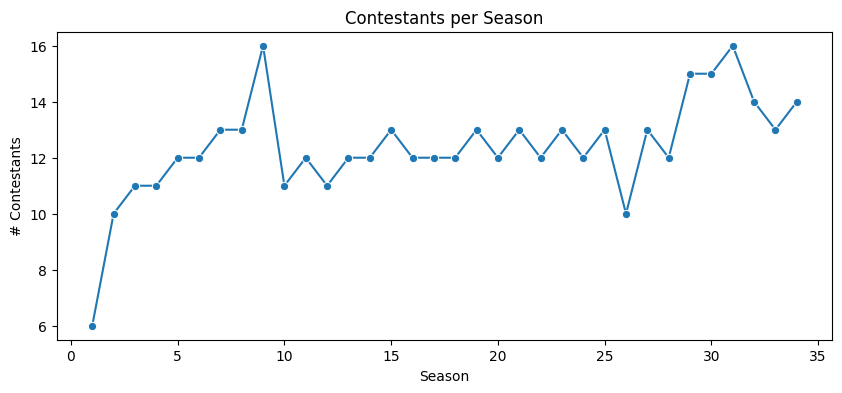

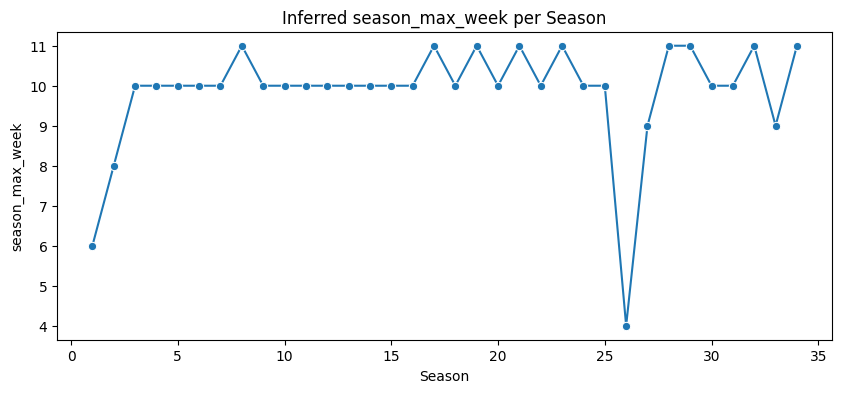

In [25]:
# Cell EDA-1: 每季参赛人数、每季最大周数（赛制规模与长度）
import seaborn as sns
import matplotlib.pyplot as plt

season_summary = (
    df_clean.groupby("season")
    .agg(
        n_contestants=("celebrity_name","nunique"),
        season_max_week=("season_max_week","max"),
        n_withdrew=("is_withdrew","sum"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,4))
sns.lineplot(data=season_summary, x="season", y="n_contestants", marker="o", ax=ax)
ax.set_title("Contestants per Season")
ax.set_xlabel("Season"); ax.set_ylabel("# Contestants")
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
sns.lineplot(data=season_summary, x="season", y="season_max_week", marker="o", ax=ax)
ax.set_title("Inferred season_max_week per Season")
ax.set_xlabel("Season"); ax.set_ylabel("season_max_week")
plt.show()


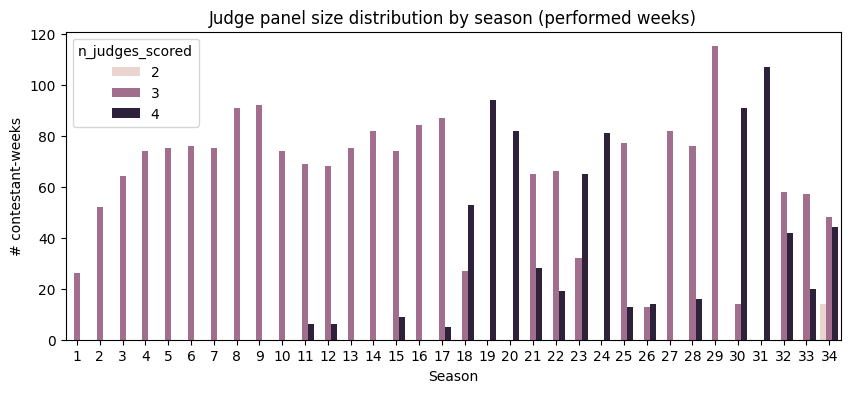

In [26]:
# Cell EDA-2: 评委人数（3/4评委）随赛季变化（结构性差异必须控制）
judge_panel = (
    df_weekly[df_weekly["performed"]]
    .groupby(["season","n_judges_scored"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=judge_panel, x="season", y="count", hue="n_judges_scored", ax=ax)
ax.set_title("Judge panel size distribution by season (performed weeks)")
ax.set_xlabel("Season"); ax.set_ylabel("# contestant-weeks")
ax.legend(title="n_judges_scored")
plt.xticks(rotation=0)
plt.show()


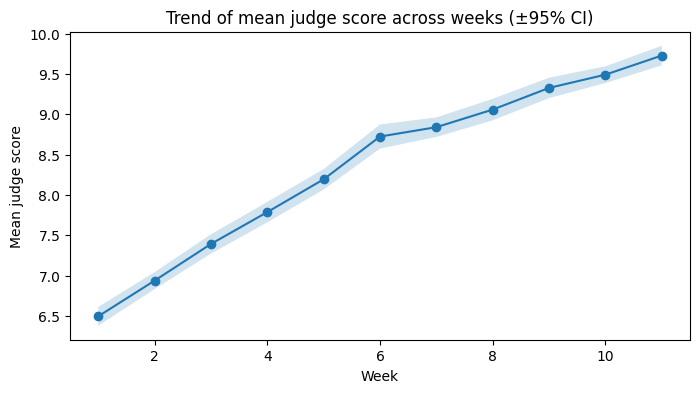

In [27]:
# Cell EDA-3: 分数随周数的“均值趋势 + 不确定性”（用 mean_judge_score 规避评委人数差异）
week_trend = (
    df_weekly[df_weekly["performed"]]
    .groupby("week")
    .agg(mean=("mean_judge_score","mean"),
         std=("mean_judge_score","std"),
         n=("mean_judge_score","size"))
    .reset_index()
)
week_trend["se"] = week_trend["std"] / (week_trend["n"] ** 0.5)
week_trend["ci95"] = 1.96 * week_trend["se"]

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(week_trend["week"], week_trend["mean"], marker="o")
ax.fill_between(week_trend["week"],
                week_trend["mean"]-week_trend["ci95"],
                week_trend["mean"]+week_trend["ci95"],
                alpha=0.2)
ax.set_title("Trend of mean judge score across weeks (±95% CI)")
ax.set_xlabel("Week"); ax.set_ylabel("Mean judge score")
plt.show()


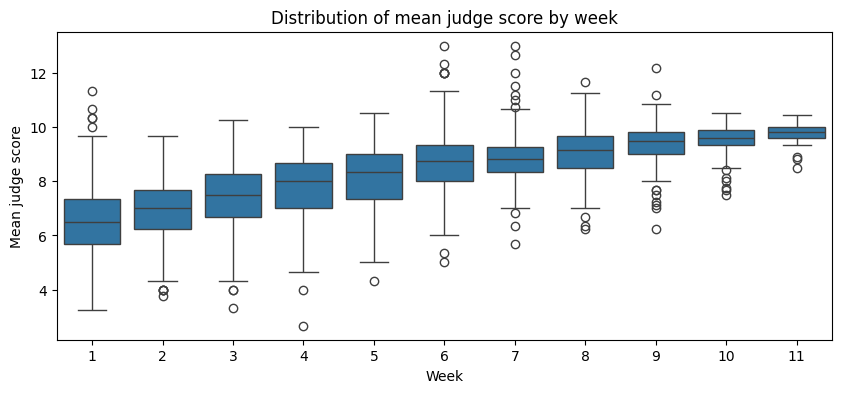

In [28]:
# Cell EDA-4: 每周分布（箱线图）——看“后期方差变小/分数天花板”
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df_weekly[df_weekly["performed"]], x="week", y="mean_judge_score", ax=ax)
ax.set_title("Distribution of mean judge score by week")
ax.set_xlabel("Week"); ax.set_ylabel("Mean judge score")
plt.show()


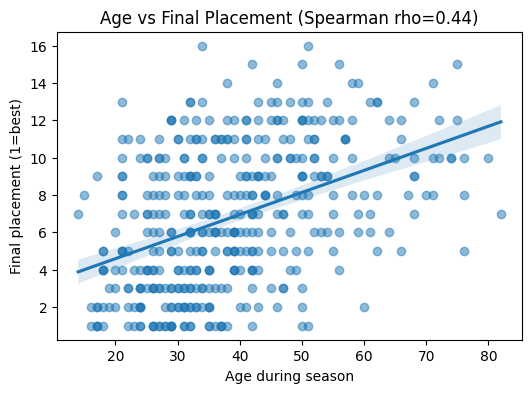

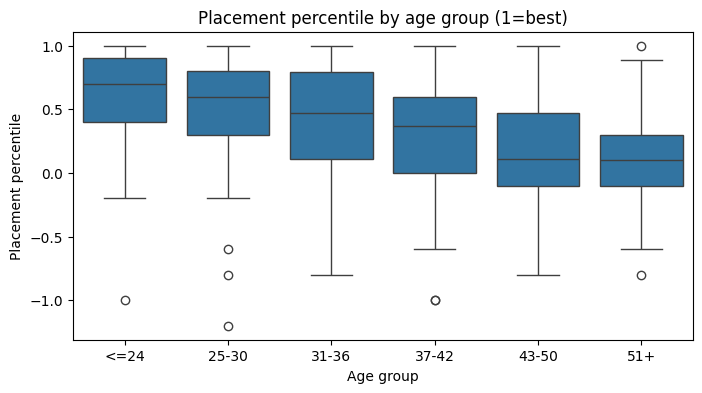

In [29]:
# Cell EDA-5: 年龄与最终名次（相关性 + 分组）
from scipy.stats import spearmanr

tmp = df_clean.copy()
rho, p = spearmanr(tmp["celebrity_age_during_season"], tmp["placement"])

fig, ax = plt.subplots(figsize=(6,4))
sns.regplot(data=tmp, x="celebrity_age_during_season", y="placement", scatter_kws={"alpha":0.5}, ax=ax)
ax.set_title(f"Age vs Final Placement (Spearman rho={rho:.2f})")
ax.set_xlabel("Age during season"); ax.set_ylabel("Final placement (1=best)")
plt.show()

bins=[0,24,30,36,42,50,100]
labels=["<=24","25-30","31-36","37-42","43-50","51+"]
tmp["age_group"]=pd.cut(tmp["celebrity_age_during_season"], bins=bins, labels=labels, include_lowest=True)

# 归一化名次：1最好、0最差（不同赛季人数可比）
tmp["n_contestants_season"] = tmp["season"].map(tmp.groupby("season")["celebrity_name"].transform("nunique"))
tmp["placement_pct"] = 1 - (tmp["placement"]-1)/(tmp["n_contestants_season"]-1)

fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=tmp, x="age_group", y="placement_pct", ax=ax)
ax.set_title("Placement percentile by age group (1=best)")
ax.set_xlabel("Age group"); ax.set_ylabel("Placement percentile")
plt.show()


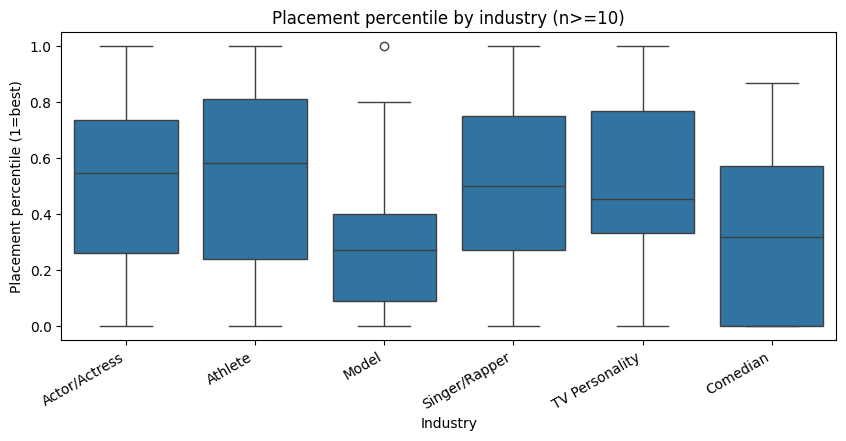

In [30]:
# Cell EDA-6: 行业与名次（仅比较样本量>=10的行业，避免 n=1 的噪声）
tmp = df_clean.copy()
tmp["n_contestants_season"] = tmp.groupby("season")["celebrity_name"].transform("nunique")
tmp["placement_pct"] = 1 - (tmp["placement"]-1)/(tmp["n_contestants_season"]-1)

ind_n = tmp["celebrity_industry"].value_counts()
keep_inds = ind_n[ind_n >= 10].index
tmp2 = tmp[tmp["celebrity_industry"].isin(keep_inds)].copy()

fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=tmp2, x="celebrity_industry", y="placement_pct", ax=ax)
ax.set_title("Placement percentile by industry (n>=10)")
ax.set_xlabel("Industry"); ax.set_ylabel("Placement percentile (1=best)")
plt.xticks(rotation=30, ha="right")
plt.show()


In [32]:
df_weekly.columns

Index(['season', 'celebrity_name', 'week', 'total_judge_score', 'mean_judge_score', 'n_judges_scored', 'performed', 'ballroom_partner', 'celebrity_industry',
       'celebrity_homestate', 'celebrity_homecountry_region', 'celebrity_age_during_season', 'results', 'placement', 'season_max_week', 'active_until',
       'elim_week_result', 'is_withdrew', 'is_place', 'eligible', 'judge_rank', 'judge_percent'],
      dtype='object')

/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_10196/1816375952.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wk["eliminated_end_week"] = wk["eliminated_end_week"].fillna(False)


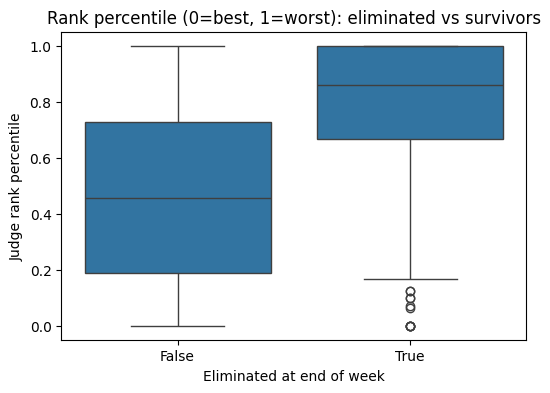

Shock eliminations (top quartile by judges): 19 / 300


,season,week,celebrity_name,judge_rank,n_performed_week,rank_pct
2051,27,8,Juan Pablo Di Pace,1.0,6,0.000000
972,14,9,Maria Menounos,1.0,4,0.000000
1875,24,9,Simone Biles,1.0,4,0.000000
1828,24,6,Heather Morris,1.0,8,0.000000
1697,22,9,Wanya Morris,1.0,5,0.000000
1209,17,5,Christina Milian,1.5,9,0.062500
1077,15,6,Sabrina Bryan,1.5,8,0.071429
1647,22,8,Jodie Sweetin,1.5,6,0.100000
1539,21,9,Alexa PenaVega,1.5,6,0.100000
2157,28,6,Sailor Brinkley-Cook,2.0,9,0.125000


In [33]:
# Cell EDA-8: “淘汰者”在当周评委名次中的位置（找爆冷证据）
# 构造：当周末被淘汰 = 本周eligible且下周不eligible（排除决赛自然结束）
elim_map=[]
for _, r in df_elim_events.iterrows():
    if r["is_final_week_end"]:
        continue
    for name in r["eliminated"]:
        elim_map.append((r["season"], r["elim_at_end_of_week"], name, True))
df_elim_flag = pd.DataFrame(elim_map, columns=["season","week","celebrity_name","eliminated_end_week"])

wk = df_weekly[(df_weekly["performed"]) & (df_weekly["eligible"])].copy()
wk = wk.merge(df_elim_flag, on=["season","week","celebrity_name"], how="left")
wk["eliminated_end_week"] = wk["eliminated_end_week"].fillna(False)

wk["n_performed_week"] = wk.groupby(["season","week"])["celebrity_name"].transform("count")
wk["rank_pct"] = (wk["judge_rank"]-1)/(wk["n_performed_week"]-1)  # 0最好, 1最差

fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=wk, x="eliminated_end_week", y="rank_pct", ax=ax)
ax.set_title("Rank percentile (0=best, 1=worst): eliminated vs survivors")
ax.set_xlabel("Eliminated at end of week"); ax.set_ylabel("Judge rank percentile")
plt.show()

shock = wk[wk["eliminated_end_week"] & (wk["rank_pct"]<=0.25)]
print("Shock eliminations (top quartile by judges):", shock.shape[0], "/", int(wk["eliminated_end_week"].sum()))
display(shock.sort_values(["rank_pct"]).head(10)[["season","week","celebrity_name","judge_rank","n_performed_week","rank_pct"]])
